In [78]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.datasets.speech_commands.config import ALL_KEYWORDS, CANONICAL, COMMAND_KEYWORDS_20, COMMAND_KEYWORDS_24
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.architectures.keyword_spotting import KeyWordSpottingModel, KeyWordSpottingConfig, SpectrogramConfig, BackboneConfig, NoiseConfig, DatasetConfig



In [79]:
SKIP_TRAINING = False

KEY_WORDS_LIST = CANONICAL  # COMMAND_KEYWORDS_20  # COMMAND_KEYWORDS_24  # ALL_KEYWORDS  # CANONICAL

In [ ]:
#CONFIGURATION and model initialization
spec_cfg=SpectrogramConfig(
    sample_rate=16000,
    n_fft=512,
)
backbone_cfg=BackboneConfig(
    n_channels_ext=128,
    n_channels_int=128,
    kernel_size=3,
    dropout=0.1,
    causal=True,
    n_blocks_pr_stack=3,
    dilation_base=2,
    n_stacks=3,
    residual_in_blocks=True,
    residual_in_stacks=False,
    use_custom_pw=True,
)

dataset_cfg=DatasetConfig(
    key_words=KEY_WORDS_LIST,
    use_unknown=True,
    use_silence=True,
    upsample=False,
)

noise_cfg=NoiseConfig(
    add_noise=True,
    noise_prob=0.8,
    snr=(-5, 15))

cfg = KeyWordSpottingConfig(
    spectrogram=spec_cfg,
    backbone=backbone_cfg,
    dataset = dataset_cfg,
    noise=noise_cfg,
)

model = KeyWordSpottingModel(cfg)

In [93]:
# print how many model parameters we have
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized with {n_params/1e3:.1f}k trainable parameters")

Model initialized with 440.1k trainable parameters


In [81]:
# --- Load YAML file ---
#config_path = Path("/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/architectures/keyword_spotting/keyword_spotting_config.yaml")
#with open(config_path, "r") as f:
#    raw_cfg = yaml.safe_load(f)

    # --- Parse and validate with Pydantic ---
#     cfg = KeyWordSpottingConfig(
#         spectrogram=SpectrogramConfig(**raw_cfg["spectrogram"]),
#         backbone=BackboneConfig(**raw_cfg["backbone"]),
#         noise=NoiseConfig(**raw_cfg["noise"]),
#         num_classes=NUM_CLASSES,
#     )
# model = KeyWordSpottingModel(cfg)

In [82]:
data_dir = get_data_dir()

train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **cfg.noise.model_dump())

val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **cfg.noise.model_dump())

In [83]:
# Training configuration
batch_size = 64
num_epochs = 10
learning_rate = 0.001

torch.manual_seed(42)
np.random.seed(42)

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Create data loaders (no num_workers for MPS compatibility)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# Move model to device
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Using MPS


In [84]:
def validate_model(model, val_loader, criterion, device, snr_values=None, verbose=True):
    """
    Evaluate `model` on the same validation set for different SNR values.

    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveform, label, meta).
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results = {}

    ds = val_loader.dataset  # the dataset bound to this loader

    with torch.no_grad():
        for snr in snr_values:
            # ---- SET THE SNR FOR THIS PASS ----
            ds._set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)
            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                logits = model(waveforms)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                total_correct += (preds == labels).sum().item()

                # live progress
                pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{100 * total_correct / total_samples:.2f}%",
                )

            avg_loss = total_loss / total_samples
            avg_acc = 100.0 * total_correct / total_samples

            results[snr] = {"loss": avg_loss, "acc": avg_acc}

            if verbose:
                print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results

In [85]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# Which SNRs you want to evaluate at each epoch
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]  # inf means no noise added
MAIN_VAL_SNR = float('inf')  # which SNR to use as "main" val metric (for curves)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],   # for MAIN_VAL_SNR
    "val_acc": [],    # for MAIN_VAL_SNR
    "val_per_snr": [] # list of dicts: {snr: {"loss": ..., "acc": ...}, ...}
}

if not SKIP_TRAINING:
    for epoch in range(num_epochs):
        # ----------------------- TRAINING -----------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for waveforms, labels, _ in train_pbar:  # Dataset returns (waveform, label, metadata)
            waveforms, labels = waveforms.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            # Stats
            batch_size = waveforms.size(0)
            train_total += batch_size
            train_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        # Use train_total to be robust to drop_last, etc.
        train_loss_epoch = train_loss / train_total
        train_acc_epoch = 100.0 * train_correct / train_total

        # ----------------------- VALIDATION -----------------------
        val_results = validate_model(
            model,
            val_loader,
            criterion,
            device,
            snr_values=VAL_SNR_VALUES,
            verbose=False,
        )

        # Pick the "main" validation metric (e.g., clean SNR=None)
        main_val = val_results[MAIN_VAL_SNR]
        val_loss_epoch = main_val["loss"]
        val_acc_epoch = main_val["acc"]

        # ----------------------- LOGGING / HISTORY -----------------------
        history["train_loss"].append(train_loss_epoch)
        history["train_acc"].append(train_acc_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["val_acc"].append(val_acc_epoch)
        history["val_per_snr"].append(val_results)

        # Epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.2f}%")
        print(f"  Val Loss (SNR={MAIN_VAL_SNR}): {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.2f}%")

        print("\n=== Val Accuracy per SNR ===")
        for snr, stats in val_results.items():
            print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
        print("-" * 60)

    print("Training completed!")
    torch.save(model.state_dict(), "keyword_spotting_model.pth")


Epoch 1/10 [Train]: 100%|██████████| 582/582 [00:44<00:00, 13.03it/s, loss=1.7700, acc=39.26%]



Epoch 1/10 Summary:
  Train Loss: 2.3192, Train Acc: 39.26%
  Val Loss (SNR=inf): 1.1500, Val Acc: 64.92%

=== Val Accuracy per SNR ===
  SNR=    -5: acc=50.32%  loss=1.5306
  SNR=     0: acc=61.82%  loss=1.1587
  SNR=     5: acc=66.49%  loss=0.9987
  SNR=    10: acc=69.10%  loss=0.9451
  SNR=    15: acc=70.25%  loss=0.9255
  SNR=   inf: acc=64.92%  loss=1.1500
------------------------------------------------------------


Epoch 2/10 [Train]: 100%|██████████| 582/582 [00:47<00:00, 12.15it/s, loss=1.1574, acc=70.18%]



Epoch 2/10 Summary:
  Train Loss: 0.9340, Train Acc: 70.18%
  Val Loss (SNR=inf): 0.7198, Val Acc: 80.20%

=== Val Accuracy per SNR ===
  SNR=    -5: acc=62.04%  loss=1.2723
  SNR=     0: acc=75.24%  loss=0.7781
  SNR=     5: acc=80.47%  loss=0.5999
  SNR=    10: acc=82.06%  loss=0.5606
  SNR=    15: acc=83.48%  loss=0.5451
  SNR=   inf: acc=80.20%  loss=0.7198
------------------------------------------------------------


Epoch 3/10 [Train]: 100%|██████████| 582/582 [00:48<00:00, 11.90it/s, loss=1.0194, acc=78.24%]


...


Epoch 8/10 Summary:
  Train Loss: 0.4624, Train Acc: 85.36%
  Val Loss (SNR=inf): 0.3921, Val Acc: 89.97%

=== Val Accuracy per SNR ===
  SNR=    -5: acc=78.87%  loss=0.7007
  SNR=     0: acc=85.63%  loss=0.4456
  SNR=     5: acc=88.99%  loss=0.3668
  SNR=    10: acc=89.97%  loss=0.3313
  SNR=    15: acc=90.19%  loss=0.3229
  SNR=   inf: acc=89.97%  loss=0.3921
------------------------------------------------------------


Epoch 9/10 [Train]: 100%|██████████| 582/582 [00:44<00:00, 12.95it/s, loss=0.2880, acc=85.97%]



Epoch 9/10 Summary:
  Train Loss: 0.4506, Train Acc: 85.97%
  Val Loss (SNR=inf): 0.3712, Val Acc: 90.37%

=== Val Accuracy per SNR ===
  SNR=    -5: acc=79.53%  loss=0.6360
  SNR=     0: acc=86.47%  loss=0.4105
  SNR=     5: acc=89.50%  loss=0.3310
  SNR=    10: acc=90.61%  loss=0.2968
  SNR=    15: acc=91.12%  loss=0.2835
  SNR=   inf: acc=90.37%  loss=0.3712
------------------------------------------------------------


Epoch 10/10 [Train]: 100%|██████████| 582/582 [00:49<00:00, 11.80it/s, loss=0.4908, acc=86.71%]
                                                                                 


Epoch 10/10 Summary:
  Train Loss: 0.4158, Train Acc: 86.71%
  Val Loss (SNR=inf): 0.3121, Val Acc: 91.81%

=== Val Accuracy per SNR ===
  SNR=    -5: acc=79.80%  loss=0.6207
  SNR=     0: acc=86.95%  loss=0.3933
  SNR=     5: acc=90.21%  loss=0.3302
  SNR=    10: acc=91.36%  loss=0.2851
  SNR=    15: acc=91.38%  loss=0.2948
  SNR=   inf: acc=91.81%  loss=0.3121
------------------------------------------------------------
Training completed!


In [86]:
import matplotlib.pyplot as plt
import math

def plot_history_with_snr_avg(
    history: dict,
    main_val_snr: float = float('inf'),
    snrs_for_avg: list[float] | None = None,
):
    """
    Plot train/val loss and accuracy, plus the average val metrics across SNRs.

    Args:
        history: dict filled during training (as in your code).
        main_val_snr: SNR that was used for history["val_loss"] / ["val_acc"].
        snrs_for_avg: Which SNRs to include in the average. 
                      If None, uses all SNRs found in val_per_snr for each epoch.
    """
    train_loss = history["train_loss"]
    train_acc  = history["train_acc"]
    val_loss   = history["val_loss"]   # main SNR
    val_acc    = history["val_acc"]    # main SNR
    val_per_snr = history["val_per_snr"]

    num_epochs = len(train_loss)
    epochs = range(1, num_epochs + 1)

    # --- Compute average val metrics across SNRs for each epoch ---
    val_loss_avg = []
    val_acc_avg = []

    for epoch_dict in val_per_snr:  # one dict per epoch: {snr: {"loss": ..., "acc": ...}}
        # Decide which SNRs to include in the average for this epoch
        if snrs_for_avg is None:
            snrs = list(epoch_dict.keys())
        else:
            snrs = [s for s in snrs_for_avg if s in epoch_dict]

        losses = [epoch_dict[snr]["loss"] for snr in snrs]
        accs   = [epoch_dict[snr]["acc"]  for snr in snrs]

        val_loss_avg.append(sum(losses) / len(losses))
        val_acc_avg.append(sum(accs) / len(accs))

    # --- Plot: Loss ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss,   label=f"Val Loss (SNR={main_val_snr})")
    plt.plot(epochs, val_loss_avg, label="Val Loss (avg over SNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Plot: Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, val_acc,   label=f"Val Acc (SNR={main_val_snr})")
    plt.plot(epochs, val_acc_avg, label="Val Acc (avg over SNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy vs Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


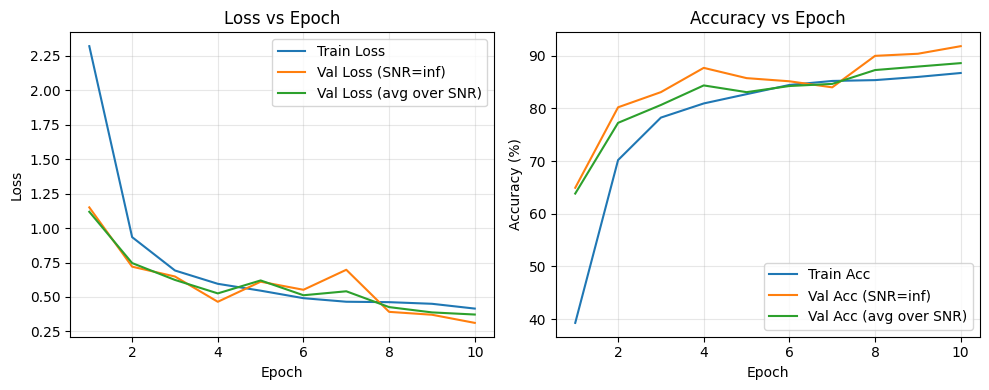

In [87]:
plot_history_with_snr_avg(history, main_val_snr=MAIN_VAL_SNR,
                          snrs_for_avg=VAL_SNR_VALUES)

In [88]:
# load the model
model.load_state_dict(torch.load("keyword_spotting_model.pth"))

<All keys matched successfully>

In [89]:
def evaluate_rank_sweep(
    model,
    compressible_layers,
    validate_fn,
    val_loader,
    criterion,
    device,
    max_rank,
    step=4,
    compress_frontend=False,
    verbose=True,
):
    """
    Sweep across target ranks for CPC_Conv1d layers and record validation accuracy.

    Args:
        model (nn.Module): Your model containing CPC_Conv1d layers.
        compressible_layers (list[tuple[str, nn.Module]]): (name, layer) pairs of CPC_Conv1d layers.
        validate_fn (callable): Validation function (model, val_loader, criterion, device) -> (val_loss, val_acc)
        val_loader (DataLoader): Validation dataloader.
        criterion (nn.Module): Loss function.
        device (torch.device): Torch device.
        max_rank (int): Maximum rank (usually = in_channels = out_channels).
        step (int, optional): Step size for the rank sweep. Default = 4.
        compress_frontend (bool, optional): If False, skip compressing the "frontend" layer.
        verbose (bool, optional): Print progress messages.

    Returns:
        list[tuple[int, float]]: List of (target_rank, val_acc) results.
    """
    val_acc_results = []

    for target_rank in range(step, max_rank + 1, step):
        # --- Activate low-rank ---
        for name, layer in compressible_layers:
            if (not compress_frontend) and (name == "frontend"):
                continue
            layer.activate_low_rank(rank=target_rank)

        # --- Validate ---
        val_loss, val_acc, per_noise = validate_fn(model, val_loader, criterion, device, verbose=False)
        val_acc_results.append((target_rank, per_noise))

        if verbose:
            print(f"[Rank {target_rank:>3}] Val Acc: {val_acc:.3f}")
            for np, v in per_noise.items():
                print(f"  noise={np:>6}: acc={v['acc']:.2f}%  loss={v['loss']:.4f}")

    return val_acc_results


In [90]:
def plot_rank_vs_accuracy_by_noise(
    results,                 # list of (rank: int, per_noise: dict[noise_param -> {'acc': float, 'loss': float}])
    title=None,
    save_path=None,
    metric="acc",            # "acc" or "loss"
    show_flops=True,         # keep the secondary y-axis like before
):
    """
    Plot {metric} vs. rank with one curve per noise_param.

    Example input:
    results = [
        (4, {0.0:{'acc':14.76,'loss':4.07}, 0.05:{'acc':21.62,'loss':4.06}}),
        (8, {0.0:{'acc':20.65,'loss':4.06}, 0.05:{'acc':34.11,'loss':4.05}})
    ]
    """

    # --- collect and sort ranks ---
    ranks = sorted(int(r) for r, _ in results)
    rank_to_dict = {int(r): d for r, d in results}

    # --- gather all noise params across ranks ---
    all_noise = set()
    for d in rank_to_dict.values():
        for k in d.keys():
            try:
                all_noise.add(float(k))
            except Exception:
                # ignore non-numeric noise keys
                pass
    noise_params = sorted(all_noise)  # numeric sort

    # --- build series per noise param aligned to 'ranks' order ---
    series = {}  # noise_param -> list of metric values aligned with ranks
    for np_val in noise_params:
        vals = []
        for r in ranks:
            entry = rank_to_dict[r].get(np_val, None)
            if entry is None or metric not in entry:
                vals.append(np.nan)  # missing value creates a gap in the curve
            else:
                vals.append(entry[metric])
        series[np_val] = vals

    # --- relative FLOPs for PW conv (same as your original logic) ---
    C = max(ranks) if ranks else 1
    flops_rel = [2 * r / C for r in ranks]  # =1 when r=C/2

    # --- plot ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # left axis: metric per noise
    for np_val, vals in series.items():
        ax1.plot(ranks, vals, marker='o', label=f"noise std={np_val:g}")

    ax1.set_xlabel("Target Rank")
    ylab = "Validation Accuracy (%)" if metric == "acc" else "Validation Loss"
    ax1.set_ylabel(ylab)
    ax1.grid(True, alpha=0.4)

    # helpful vertical reference at C//2
    ax1.axvline(x=C // 2, color='r', linestyle='--', linewidth=1, label='Max Rank // 2')

    # right axis: relative FLOPs (optional)
    if show_flops:
        ax2 = ax1.twinx()
        ax2.plot(ranks, flops_rel, linestyle='-', alpha=0.6, label="Relative PW FLOPs")
        ax2.set_ylabel("Relative PW FLOPs (vs full conv)")
        # Handle legends from both axes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax1.legend(loc="best")

    # title
    if title is None:
        base = "Validation Accuracy vs. Target Rank" if metric == "acc" \
               else "Validation Loss vs. Target Rank"
        if show_flops:
            base += " (with Relative PW FLOPs)"
        title = base
    plt.title(title)

    # save or show
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
        plt.close(fig)
    else:
        plt.tight_layout()
        plt.show()


In [91]:
from thesis_project.models.blocks import CPC_Conv1d
compressible_layers = []
for name, layer in model.named_modules():
    if isinstance(layer, CPC_Conv1d):
        W = layer.weight_full.squeeze(-1)
        max_rank = min(W.shape)
        print(f"{name}: max_rank = {max_rank}")
        compressible_layers.append((name, layer))

backbone.0.0.cpw_conv1: max_rank = 128
backbone.0.0.cpw_conv2: max_rank = 128
backbone.0.1.cpw_conv1: max_rank = 128
backbone.0.1.cpw_conv2: max_rank = 128
backbone.0.2.cpw_conv1: max_rank = 128
backbone.0.2.cpw_conv2: max_rank = 128
backbone.1.0.cpw_conv1: max_rank = 128
backbone.1.0.cpw_conv2: max_rank = 128
backbone.1.1.cpw_conv1: max_rank = 128
backbone.1.1.cpw_conv2: max_rank = 128
backbone.1.2.cpw_conv1: max_rank = 128
backbone.1.2.cpw_conv2: max_rank = 128
backbone.2.0.cpw_conv1: max_rank = 128
backbone.2.0.cpw_conv2: max_rank = 128
backbone.2.1.cpw_conv1: max_rank = 128
backbone.2.1.cpw_conv2: max_rank = 128
backbone.2.2.cpw_conv1: max_rank = 128
backbone.2.2.cpw_conv2: max_rank = 128
backbone.3.0.cpw_conv1: max_rank = 128
backbone.3.0.cpw_conv2: max_rank = 128
backbone.3.1.cpw_conv1: max_rank = 128
backbone.3.1.cpw_conv2: max_rank = 128
backbone.3.2.cpw_conv1: max_rank = 128
backbone.3.2.cpw_conv2: max_rank = 128
frontend: max_rank = 128


In [92]:
results = {}

results["val_acc_results"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model_per_noise,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    step=4,
    compress_frontend=False,
    verbose=True
)

NameError: name 'validate_model_per_noise' is not defined

In [ ]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results"],
    title="Validation Accuracy vs. Target Rank (Uncompressed Frontend)",
    metric="acc",
    show_flops=True
)

### COMPRESSED FRONTEND RESULTS

In [ ]:
results["val_acc_results_compressed_frontend"] = evaluate_rank_sweep(
    model=model,
    compressible_layers=compressible_layers,
    validate_fn=validate_model_per_noise,
    val_loader=val_loader,
    criterion=criterion,    
    device=device,
    max_rank=128, #128
    step=4,
    compress_frontend=True,
    verbose=True
)

In [ ]:
plot_rank_vs_accuracy_by_noise(
    results=results["val_acc_results_compressed_frontend"],
    title="Validation Accuracy vs. Target Rank (Compressed Frontend)",
    metric="acc",
    show_flops=True
)